# Workshop 1 — Análisis Exploratorio de Datos (EDA) con NumPy y Pandas

**Curso:** Fundamentos de Aprendizaje Automático
**Dataset asignado:** [Used Car Prices](https://www.kaggle.com/datasets/sujay1844/used-car-prices) (Cars24)
**Fecha:** 2026-08-11

## Integrantes del equipo

- Juan José Escobar Saldarriaga
- Jeremías Figueroa García
- David Quintero Gallego

## Repositorio

Link del repositorio de GitHub: `https://github.com/Jjes07/FundamentosML-Workshop1`

---

# Fase 0 - Importación de librerias y Drive

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


**En caso de trabajar con Google Colab, es necesario descargar el dataset en Drive y conectar el notebook con drive:**

In [ ]:
from google.colab import drive
import sys
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/Colab Notebooks/data'
#puede confirmar su ubicación mediante:
%ls

# Fase 1 — Reconocimiento inicial del dataset

## 1. Tema y contexto del dataset

El dataset agrupa información de anuncios de venta de vehículos usados publicados en la plataforma india **Cars24**. Cada fila representa un vehículo usado individual y cada columna describe un atributo de ese vehículo, por lo que la estructura de los datos es completamente **tabular**.

La **variable objetivo (target)** es `Price`: el precio de venta del vehículo usado, expresado en **lakhs**, una unidad de la numeración india equivalente a 100.000 rupias (por ejemplo, un valor de `4.5` en `Price` corresponde a 4.5 lakh ≈ 450.000 rupias). Por lo tanto, el problema de fondo que sugiere este dataset es un problema de **regresión**: estimar el precio de reventa de un carro usado a partir de sus características.

El dataset cuenta con 12 atributos (features) además de la variable objetivo y una columna inicial sin nombre:

* Columna sin nombre, posible ID secuencial (`Unnamed:0`)
* Marca y modelo del carro (`Name`)
* Ciudad de venta (`Location`)
* Año de fabricación (`Year`)
* Rendimiento de combustible / mileage (`Mileage`)
* Kilómetros recorridos — odómetro (`Kilometers_Driven`)
* Tipo de combustible: gasolina o diesel (`Fuel_Type`)
* Tipo de transmisión: manual o automática (`Transmission`)
* Número de dueños previos (`Owner_Type`)
* Cilindraje del motor (`Engine`)
* Potencia del motor (`Power`)
* Número de asientos (`Seats`)
* Precio del carro cuando era nuevo (`New_Price`)
* Precio de venta del carro usado (`Price`)

## 2. Primeras y últimas filas del dataset

Cargue el dataset con pandas y muestre las primeras y últimas 5 filas usando `.head()` y `.tail()`.

In [2]:
df = pd.read_csv('data/train.csv')

# Primeras 5 filas del DataFrame
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [3]:
# ültimas 5 filas del DataFrame
df.tail()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
5842,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75
5843,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,NaN,4.00
5844,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,NaN,2.90
5845,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,NaN,2.65
5846,6018,Chevrolet Beat Diesel,Hyderabad,2011,47000,Diesel,Manual,First,25.44 kmpl,936 CC,57.6 bhp,5.0,NaN,2.50


De primera impresión, se puede observar algunos datos que podrían ser relevantes como:
- Existe una columna sin nombre, la cual se podría tratar de un identificador (ID), sin embargo existen varios saltos entre algunos números en esta columna.
- Además, parece que el atributo "New_Price" posiblemente tendrá una cantidad considerable de datos nulos.

## 3. Dimensiones y diccionario de datos

Use `.shape` para reportar cuántas filas y columnas tiene el dataset.

In [4]:
df.shape

(5847, 14)

**Filas:** `5847`
**Columnas:** `14`

### Diccionario de datos

| Columna | Tipo de dato esperado | Descripción |
|---|---|---|
| `Unnamed:0` | Numérica discreta (entero) — **No aporta info** | Posiblemente un ID del dataset original |
| `Name` | Categórica (texto) | Marca y modelo del vehículo |
| `Location` | Categórica (texto) | Ciudad donde se vende el vehículo |
| `Year` | Numérica (entero) | Año de fabricación |
| `Kilometers_Driven` | Numérica (entero) | Kilómetros recorridos (odómetro) |
| `Fuel_Type` | Categórica | Tipo de combustible (Petrol, Diesel, ...) |
| `Transmission` | Categórica | Tipo de transmisión (Manual, Automatic) |
| `Owner_Type` | Categórica ordinal | Número de dueños previos (First, Second, ...) |
| `Mileage` | Numérica continua (texto con unidad) | Rendimiento de combustible (kmpl o km/kg) |
| `Engine` | Numérica continua (texto con unidad) | Cilindraje del motor en cc |
| `Power` | Numérica continua (texto con unidad) | Potencia del motor en bhp |
| `Seats` | Numérica (punto flotante) | Número de asientos |
| `New_Price` | Numérica continua (texto con unidad) | Precio del carro cuando era nuevo, en lakhs |
| `Price` | Numérica continua — **variable objetivo** | Precio de reventa del carro usado, en lakhs |

*Nota: varias columnas numéricas (`Mileage`, `Engine`, `Power`, `New_Price`) llegan como texto porque incluyen la unidad de medida; requieren limpieza para convertirse a tipo numérico.*

## 4. Tipos de datos

Use `.info()` y `.dtypes` para identificar qué columnas son numéricas, categóricas o de fecha.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   str    
 2   Location           5847 non-null   str    
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   str    
 6   Transmission       5847 non-null   str    
 7   Owner_Type         5847 non-null   str    
 8   Mileage            5845 non-null   str    
 9   Engine             5811 non-null   str    
 10  Power              5811 non-null   str    
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    str    
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), str(9)
memory usage: 639.6 KB


In [6]:
df.dtypes

Unnamed: 0             int64
Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage                  str
Engine                   str
Power                    str
Seats                float64
New_Price                str
Price                float64
dtype: object

En este paso, logramos identificar varios factores:
- El dataset solo contiene columnas con datos tipo Integer, Float y String.
- Con el `.info()` verificamos que la columna de `New_Price` solo tiene 815 registros no nulos de un total 5847 entradas.
- Existen otras columnas que cuentan con algunos pocos nulos como `Seats`, `Power`, `Engine` y `Mileage`.
- Como se mencionó anteriormente, algunas columnas con valores strings en realidad deben pasarse a tipo numético.

## 5. Estadísticos descriptivos

Use `.describe()` para las columnas numéricas. Interprete al menos 3 estadísticos (media, desviación estándar, mínimo/máximo) en términos del problema, no solo como números.

In [7]:
df[['Year', 'Kilometers_Driven', 'Seats', 'Price']].describe()

,Year,Kilometers_Driven,Seats,Price
count,5847.000000,5.847000e+03,5809.000000,5847.000000
mean,2013.448435,5.841013e+04,5.286452,9.653742
std,3.194949,9.237971e+04,0.806668,11.275966
min,1998.000000,1.710000e+02,2.000000,0.440000
25%,2012.000000,3.346750e+04,5.000000,3.550000
50%,2014.000000,5.257600e+04,5.000000,5.750000
75%,2016.000000,7.249050e+04,5.000000,10.250000
max,2019.000000,6.500000e+06,10.000000,160.000000


- ### Año de fabricación (`Year`)

El año de fabricación va de 1998 a 2019, con media 2013.45 y mediana 2014. Es decir, la mitad de los carros usados fueron fabricados en 2014 o en años anteriores, lo cual tiene sentido: para que un carro llegue al mercado de "usados", primero tuvo que rodar varios años con su dueño original. El caso de 2019 (año máximo) es el más llamativo: si asumimos que Cars24 recolectó estos anuncios alrededor de 2019-2024, un carro de ese año pudo haberse revendido con apenas 0 a 5 años de uso.

En el otro extremo, el carro de 1998 no necesariamente implica el mayor kilometraje: al revisarlo puntualmente, los tres carros de 1998 en el dataset tienen entre 55.300 y 95.150 km recorridos, cifras moderadas para 20+ años de antigüedad (menos de 5.000 km/año en promedio). Esto sugiere que la relación "carro más viejo = más kilómetros" no es automática; el uso real depende también de cada propietario, y habrá que confirmar esta hipótesis con el scatter plot de la Fase 4 en lugar de darla por hecha.

- ### Precio (`Price`)

Aquí sí se nota un sesgo claro: media = 9.65 lakhs, mediana (50%) = 5.75, percentil 75% = 10.25, y máximo = 160. La media está mucho más cerca del percentil 75 que de la mediana, y el máximo está muy alejado del resto de los cuartiles (160 vs. 10.25 en el percentil 75). Esto es la firma clásica de una **distribución sesgada a la derecha**: la mayoría de los carros se vende relativamente barato (la mitad por debajo de 5.75 lakhs), pero un grupo pequeño de vehículos de alta gama estira la media hacia arriba. La desviación estándar (11.28) es incluso mayor que la propia media, lo cual confirma la alta dispersión y refuerza que la media *no* es un buen resumen del "precio típico" en este dataset — la mediana es más representativa. Se debe confirmar con el histograma y el boxplot de la Fase 4.

- ### Número de asientos (`Seats`)

Los tres cuartiles centrales (25%, 50% y 75%) coinciden en 5, con media 5.29 y desviación estándar baja (0.81). Esto indica que la enorme mayoría de los carros usados en venta son de 5 puestos, la configuración estándar de un sedán o hatchback familiar. El mínimo de 2 asientos probablemente corresponde a carros deportivos o compactos de 2 puertas, y el máximo de 10 a vans o carros tipo MPV de uso familiar/comercial — ambos casos son minoría dentro del dataset, tal como sugiere la baja variabilidad general.

- ### Kilómetros recorridos (`Kilometers_Driven`)

A simple vista los cuartiles parecen razonablemente centrados (25% = 33.468, 50% = 52.576, 75% = 72.491, con la media en 58.410 apenas un poco por encima de la mediana), lo que podría sugerir una distribución simétrica. Sin embargo, la desviación estándar (92.380) es **mayor que la propia media**, señal de que algo está distorsionando la distribución — y en efecto, el máximo es 6.500.000 km, un valor físicamente imposible para un vehículo (equivaldría a más de 160 vueltas al ecuador terrestre). Se trata de un BMW X5 del 2017, casi con seguridad un error de digitación (posiblemente le sobra un dígito: pudo ser 650.000 o incluso 65.000 km). Este único outlier extremo es suficiente para inflar la desviación estándar y "esconder" el verdadero comportamiento de la variable. Conclusión: `Kilometers_Driven` **no es tan simétrica como aparenta por los cuartiles**; hay que tratar este valor en la Fase 2 (puntos 8/11) antes de sacar conclusiones sobre su forma real.

- ### Variabilidad relativa (coeficiente de variación)

Comparar desviaciones estándar en bruto entre columnas de escalas muy distintas (kilómetros vs. lakhs de precio) puede llevar a conclusiones erróneas, como pasó arriba. Una forma más justa de comparar qué tan dispersa es cada variable es el **coeficiente de variación** (CV = desviación estándar / media):

| Variable | Media | Desv. estándar | CV (std/mean) |
|---|---|---|---|
| `Kilometers_Driven` | 58,410 | 92,380 | **1.58** |
| `Price` | 9.65 | 11.28 | **1.17** |
| `Seats` | 5.29 | 0.81 | 0.15 |

Con esta métrica, `Kilometers_Driven` resulta ser **relativamente más variable** que `Price` (CV 1.58 vs 1.17), justo lo contrario de lo que sugería la intuición inicial de que el kilometraje era "la variable más simétrica y poco dispersa en términos relativos". La razón, otra vez, es el outlier del BMW X5: sin él, es probable que el CV de `Kilometers_Driven` baje considerablemente y quede más en línea con lo esperado. Esto es un buen ejemplo de por qué limpiar outliers (Fase 2) puede cambiar sustancialmente las conclusiones de un análisis descriptivo.

## 6. Cálculo manual con NumPy

Convierta al menos una columna numérica a un array de NumPy (`.values` o `.to_numpy()`) y calcule manualmente su media, mediana y desviación estándar con `np.mean`, `np.median`, `np.std`.

- Convertimos nuestras columnas numéricas a un array de numpy:

In [ ]:
df_year_array = df['Year'].to_numpy()
print("Year array:", df_year_array)

df_kilometers_array = df['Kilometers_Driven'].to_numpy()
print("Kilometers array:", df_kilometers_array)

# Debido a que hay valores nulos en la columna 'Seats', se utiliza dropna() para eliminarlos antes de convertir a un array.
# No hacerlo afectaría los siguientes cálculos (Su media, mediana y desviación estándar serían 'nan').
df_seats_array = df['Seats'].dropna().to_numpy()
print("Seats array:", df_seats_array)

df_price_array = df['Price'].to_numpy()
print("Price array:", df_price_array)

Year array: [2015 2011 2012 ... 2012 2013 2011]
Kilometers array: [41000 46000 87000 ... 55000 46000 47000]
Seats array: [5. 5. 7. ... 8. 5. 5.]
Price array: [12.5   4.5   6.   ...  2.9   2.65  2.5 ]


- Datos estadísticos de `Year`

In [ ]:
df_year_mean = np.mean(df_year_array)
df_year_median = np.median(df_year_array)
df_year_std = np.std(df_year_array)
print("Media del vector de años:", df_year_mean)
print("Mediana del vector de años:", df_year_median)
print("Desviación Estándar del vector de años:", df_year_std)

Media del vector de años: 2013.4484350949206
Mediana del vector de años: 2014.0
Desviación Estándar del vector de años: 3.19467561955803


- Datos Estadísticos de `Kilometers_Driven`

In [ ]:
df_kilometers_mean = np.mean(df_kilometers_array)
df_kilometers_median = np.median(df_kilometers_array)
df_kilometers_std = np.std(df_kilometers_array)
print("Media del vector de kilómetros:", df_kilometers_mean)
print("Mediana del vector de kilómetros:", df_kilometers_median)
print("Desviación Estándar del vector de kilómetros:", df_kilometers_std)

Media del vector de kilómetros: 58410.13459893963
Mediana del vector de kilómetros: 52576.0
Desviación Estándar del vector de kilómetros: 92371.81227696271


- Datos estadísticos de `Seats`

In [ ]:
df_seats_mean = np.mean(df_seats_array)
df_seats_median = np.median(df_seats_array)
df_seats_std = np.std(df_seats_array)
print("Media del vector de asientos:", df_seats_mean)
print("Mediana del vector de asientos:", df_seats_median)
print("Desviación Estándar del vector de asientos:", df_seats_std)

Media del vector de asientos: 5.286452057152694
Mediana del vector de asientos: 5.0
Desviación Estándar del vector de asientos: 0.8065986871146472


- Datos estadísticos de `Price`

In [ ]:
df_price_mean = np.mean(df_price_array)
df_price_median = np.median(df_price_array)
df_price_std = np.std(df_price_array)
print("Media del vector de precios:", df_price_mean)
print("Mediana del vector de precios:", df_price_median)
print("Desviación Estándar del vector de precios:", df_price_std)

Media del vector de precios: 9.653742089960664
Mediana del vector de precios: 5.75
Desviación Estándar del vector de precios: 11.275001413335396


---

# Fase 2 — Limpieza de datos (Data Cleaning)

## 7. Valores nulos por columna

Identifique valores nulos por columna con `.isnull().sum()` y calcule qué porcentaje representan del total de filas.

In [8]:
# Suma de valores nulos por columna
df.isnull().sum()

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64

In [9]:
# Porcentaje de valores nulos por columna
(df.isnull().sum() / len(df)) * 100

Unnamed: 0            0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.034206
Engine                0.615700
Power                 0.615700
Seats                 0.649906
New_Price            86.061228
Price                 0.000000
dtype: float64

## 8. Estrategia de tratamiento de nulos

Proponga y justifique una estrategia de tratamiento para los nulos encontrados (eliminar filas, imputar con media/mediana/moda, imputar con un valor constante, etc.) y aplíquela.

### Resumen de nulos encontrados

| Columna | Nulos | % del total |
|---|---|---|
| `Mileage` | 2 | 0.03% |
| `Engine` | 36 | 0.62% |
| `Power` | 36 | 0.62% |
| `Seats` | 38 | 0.65% |
| `New_Price` | 5032 | 86.06% |

### Columnas a eliminar

**`Unnamed: 0`** — se elimina, aunque no tiene ningún nulo. Es un índice heredado del archivo original que no representa ningún atributo real del vehículo, así que no aporta información para el análisis (ya señalado en el punto 2).

**`New_Price`** — se elimina, con 86.06% de nulos (solo 815 de 5847 filas, ≈13.94%, tienen dato — no ≈24% como se pensó inicialmente). Es una lástima perder esta columna: conceptualmente el precio de venta como nuevo debería actuar casi como un techo del precio de reventa (salvo excepciones como autos de colección, que rara vez se venden como "usados" comunes sino en subastas especializadas), por lo que habría sido un buen predictor. Pero con menos del 14% de los datos disponibles, cualquier imputación (media, mediana, moda, o incluso una imputación más sofisticada) introduciría más ruido que señal, y ese 14% no es representativo de todo el dataset — sobre todo considerando la alta variabilidad que ya vimos en `Price` (Fase 1, punto 5). Por eso se elimina la columna completa en lugar de imputar.

In [10]:
df.drop(columns=['Unnamed: 0', 'New_Price'], inplace=True)
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,3.50


### Columnas a imputar

**`Seats`** (38 nulos, 0.65%) — se imputa con la **moda o mediana** (ambas coinciden en 5), no con la media (5.29) redondeada. Aunque el resultado práctico es el mismo, es más correcto metodológicamente usar la moda o la mediana en una variable discreta con una distribución tan concentrada (recordar que del percentil 25% al 75% el valor es constante en 5) — la justificación estadística es más sólida que "redondear la media".

**`Engine` y `Power`** (36 nulos cada una, 0.62%) — antes de imputar es necesario convertir estas columnas de texto a numérico, quitando el sufijo `" CC"` y `" bhp"` respectivamente (ver punto 10). Ya convertidas, se imputan con la **mediana** y no con la media, porque ambas distribuciones están sesgadas a la derecha (media de `Engine` ≈ 1631 cc vs. mediana ≈ 1497 cc; media de `Power` ≈ 113.8 bhp vs. mediana ≈ 98.6 bhp) — el mismo patrón de sesgo que ya identificamos en `Price`. Además, los 36 nulos de `Engine`/`Power` corresponden exactamente a las mismas 36 filas, y 36 de las 38 filas con `Seats` nulo también coinciden con ellas: en su mayoría son los mismos autos con ficha técnica incompleta. No pertenecen a una sola marca o modelo (hay Maruti, Honda, BMW, Land Rover, Hyundai, Fiat, Toyota), así que no hay evidencia de que la falta de dato dependa de alguna categoría específica — parecen listados con información técnica incompleta en la fuente original, lo que hace razonable una imputación simple por mediana en vez de eliminar las filas.

**Nota:** Ejecutar la siguiente celda cuando se requiera transformar las columnas categóricas mencionadas a numéricas.

In [23]:
# Engine: unidad única "CC" -> se extrae el valor numérico
df['Engine'] = df['Engine'].str.replace(' CC', '', regex=False).astype(float)

# Power: unidad única "bhp" -> se extrae el valor numérico
df['Power'] = df['Power'].str.replace(' bhp', '', regex=False).astype(float)

# Mileage: dos unidades distintas ("kmpl" y "km/kg") -> se separan número y unidad,
# y los valores en km/kg se convierten a su equivalente en kmpl (factor 1.40,
# basado en la densidad del CNG) para dejar toda la columna en una sola unidad comparable.
mileage_split = df['Mileage'].str.strip().str.split(' ', n=1, expand=True)
mileage_split.columns = ['valor', 'unidad']
mileage_split['valor'] = mileage_split['valor'].astype(float)

FACTOR_KM_KG_A_KMPL = 1.40

df['Mileage'] = mileage_split.apply(
    lambda fila: fila['valor'] * FACTOR_KM_KG_A_KMPL if fila['unidad'] == 'km/kg' else fila['valor'],
    axis=1
)

# Verificación rápida: las 3 columnas ya deben ser numéricas (float)
df[['Engine', 'Power', 'Mileage']].info()
df[['Engine', 'Power', 'Mileage']].describe()

<class 'pandas.DataFrame'>
Index: 5845 entries, 0 to 5846
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Engine   5809 non-null   float64
 1   Power    5809 non-null   float64
 2   Mileage  5845 non-null   float64
dtypes: float64(3)
memory usage: 182.7 KB


,Engine,Power,Mileage
count,5809.000000,5809.000000,5845.000000
mean,1631.792391,113.822701,18.161163
std,601.724341,53.894869,4.357132
min,624.000000,34.200000,0.000000
25%,1198.000000,78.000000,15.260000
50%,1497.000000,98.600000,18.190000
75%,1991.000000,139.010000,21.100000
max,5998.000000,560.000000,28.400000


Una vez teniendo estas columnas como numéricas, ahora sí podemos proceder con la imputación con la **mediana**:

In [24]:
df.fillna({'Seats': df['Seats'].median()}, inplace=True)
df.fillna({'Engine': df['Engine'].median()}, inplace=True)
df.fillna({'Power': df['Power'].median()}, inplace=True)

df.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

### Filas a eliminar

**`Mileage`** (2 nulos, 0.03%) — antes de decidir conviene revisar *cuáles* son esas 2 filas: corresponden a los **únicos dos vehículos `Electric`** del dataset (`Mahindra E Verito D4` y `Toyota Prius`). No es casualidad: el rendimiento en kmpl o km/kg simplemente no aplica a un vehículo eléctrico, que no consume combustible líquido ni gas. Imputar con la mediana o la moda fabricaría un dato inexistente para una variable que, en este caso, no tiene sentido conceptual para esas filas. Por tratarse de una cantidad mínima (0.03%) y con una causa clara y no aleatoria, la recomendación es **eliminar esas 2 filas**.

In [25]:
df = df.dropna(subset=['Mileage'])

df.info()

<class 'pandas.DataFrame'>
Index: 5845 entries, 0 to 5846
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5845 non-null   str    
 1   Location           5845 non-null   str    
 2   Year               5845 non-null   int64  
 3   Kilometers_Driven  5845 non-null   int64  
 4   Fuel_Type          5845 non-null   str    
 5   Transmission       5845 non-null   str    
 6   Owner_Type         5845 non-null   str    
 7   Mileage            5845 non-null   float64
 8   Engine             5845 non-null   float64
 9   Power              5845 non-null   float64
 10  Seats              5845 non-null   float64
 11  Price              5845 non-null   float64
dtypes: float64(5), int64(2), str(5)
memory usage: 593.6 KB


## 9. Filas duplicadas

Identifique y elimine filas duplicadas si existen (`.duplicated()`, `.drop_duplicates()`). Reporte cuántas se eliminaron.

In [12]:
df.duplicated().sum()

np.int64(0)

**No se encontró ninguna fila duplicada** (`df.duplicated().sum()` = 0).

**Observación:** aun si se hubiesen encontrado duplicados exactos (mismos valores en las ahora 12 columnas), sería razonable tratarlos como errores de captura o de scraping (p. ej., el mismo anuncio registrado dos veces por error) y eliminarlos, y no como dos transacciones reales distintas. Esto porque, aunque atributos como `Name`, `Year`, `Fuel_Type` o `Seats` sí podrían coincidir entre dos carros del mismo modelo y año, hay al menos dos atributos que en la práctica hacen casi imposible una coincidencia exacta entre dos vehículos realmente distintos: `Kilometers_Driven` (el odómetro es casi continuo; dos autos distintos rara vez acumulan exactamente el mismo kilometraje) y `Owner_Type` (si el mismo carro se revendiera más adelante, este atributo cambiaría en el nuevo anuncio). Por lo tanto, una fila duplicada en la totalidad de sus columnas sería casi con certeza un error del proceso de recolección de datos y no una coincidencia real, así que su eliminación estaría plenamente justificada.

## 10. Inconsistencias de formato

Revise si hay inconsistencias de formato en columnas categóricas o de texto (mayúsculas/minúsculas, espacios extra, etc.) usando `.unique()` y corríjalas.

- `Name`

In [13]:
df['Name'].unique()

<StringArray>
[          'Hyundai Creta 1.6 CRDi SX Option',
                               'Honda Jazz V',
                          'Maruti Ertiga VDI',
            'Audi A4 New 2.0 TDI Multitronic',
                     'Nissan Micra Diesel XV',
          'Toyota Innova Crysta 2.8 GX AT 8S',
        'Volkswagen Vento Diesel Comfortline',
             'Tata Indica Vista Quadrajet LS',
                           'Maruti Ciaz Zeta',
                'Honda City 1.5 V AT Sunroof',
 ...
 'Mercedes-Benz New C-Class C 200 AVANTGARDE',
        'Skoda Rapid Ultima 1.6 TDI Elegance',
          'Mercedes-Benz GLA Class 200 Sport',
                            'Tata Indica LEI',
                'Hyundai i20 2015-2017 Magna',
           'Tata New Safari DICOR 2.2 VX 4x2',
                         'Hyundai Elantra SX',
 'Volkswagen Polo IPL II 1.2 Petrol Highline',
                      'Tata Bolt Revotron XT',
                      'Mahindra Xylo D4 BSIV']
Length: 1802, dtype: str

- `Location`

In [14]:
df['Location'].unique()

<StringArray>
[      'Pune',    'Chennai', 'Coimbatore',     'Jaipur',     'Mumbai',
      'Kochi',    'Kolkata',      'Delhi',  'Bangalore',  'Hyderabad',
  'Ahmedabad']
Length: 11, dtype: str

- `Fuel_Type`

In [15]:
df['Fuel_Type'].unique()

<StringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

- `Transmission`

In [16]:
df['Transmission'].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

- `Owner_type`

In [19]:
df['Owner_Type'].unique()

<StringArray>
['First', 'Second', 'Fourth & Above', 'Third']
Length: 4, dtype: str

- `Mileage`

In [20]:
df['Mileage'].unique()

<StringArray>
['19.67 kmpl',   '13 km/kg', '20.77 kmpl',  '15.2 kmpl', '23.08 kmpl',
 '11.36 kmpl', '20.54 kmpl',  '22.3 kmpl', '21.56 kmpl',  '16.8 kmpl',
 ...
 '18.59 kmpl',  '9.74 kmpl', '14.81 kmpl',   '8.2 kmpl', '12.97 kmpl',
   '7.5 kmpl',   '6.4 kmpl', '12.85 kmpl', '18.69 kmpl', '17.24 kmpl']
Length: 419, dtype: str

`Mileage` es una columna numérica con la unidad de medida incluida como texto (ej. `"19.67 kmpl"`), por lo que aquí lo "categórico" a revisar no son los valores en sí, sino sus **unidades**. Al separar el número de la unidad y mirar `.unique()` sobre esta última, aparecen **dos unidades distintas**: `kmpl` (kilómetros por litro, propia de combustibles líquidos) y `km/kg` (kilómetros por kilogramo, típica de vehículos a gas — GNC/GLP). Sin embargo, `Fuel_Type` en este dataset solo registra `Diesel`, `Petrol` y `Electric` (no existe una categoría de gas explícita), así que encontrar `km/kg` en filas etiquetadas como `Petrol`/`Diesel` (3 filas en total) puede ser una inconsistencia real entre columnas: es probable que esos vehículos sean variantes bi-combustible (gasolina/diésel + GNC) mal etiquetadas en `Fuel_Type`.

- `Engine`

In [21]:
df['Engine'].unique()

<StringArray>
['1582 CC', '1199 CC', '1248 CC', '1968 CC', '1461 CC', '2755 CC', '1598 CC',
 '1462 CC', '1497 CC', '2179 CC',
 ...
 '2771 CC', '4951 CC', '2925 CC', '2200 CC', '5000 CC', '2149 CC', '5998 CC',
 '2092 CC', '5204 CC', '1797 CC']
Length: 140, dtype: str

A diferencia de `Mileage`, `Engine` es consistente: **todas** las filas no nulas usan la misma unidad, `CC` (centímetros cúbicos), sin variaciones de mayúsculas/minúsculas ni espacios irregulares. Solo falta extraer el valor numérico eliminando el sufijo `" CC"` para poder tratar la columna como numérica (necesario, entre otras cosas, para la imputación por mediana del punto 8).

- `Power`

In [22]:
df['Power'].unique()

<StringArray>
[ '126.2 bhp',   '88.7 bhp',  '88.76 bhp',  '140.8 bhp',   '63.1 bhp',
  '171.5 bhp',  '103.6 bhp',     '74 bhp', '103.25 bhp',  '116.3 bhp',
 ...
    '382 bhp',  '74.96 bhp',    '552 bhp',    '127 bhp',    '560 bhp',
  '116.4 bhp',  '161.6 bhp',  '488.1 bhp',    '103 bhp', '181.04 bhp']
Length: 361, dtype: str

Igual que `Engine`, `Power` usa una única unidad consistente en todo el dataset: `bhp` (caballos de fuerza al freno). No se detectan inconsistencias de formato; solo se requiere extraer el valor numérico eliminando el sufijo `" bhp"`.

## 11. Outliers (criterio IQR)

Identifique posibles valores atípicos en al menos una columna numérica usando el rango intercuartílico (IQR). No es obligatorio eliminarlos, pero sí reportarlos.

*Reporte manual de outliers, con base en las operaciones de IQR vistas en clase.*

In [26]:
# Calculamos los cuartiles y el rango intercuartílico (IQR) para la columna 'Price'
Q1 = df['Price'].quantile(0.25)
Q2 = df['Price'].quantile(0.50)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1
Limite_sup = Q3 + 1.5 * IQR
Limite_inf = Q1 - 1.5 * IQR

# Identificamos los valores atípicos utilizando el IQR
outliers_inf = df[(df['Price'] < Limite_inf)].sort_values(by='Price')
outliers_sup = df[(df['Price'] > Limite_sup)].sort_values(by='Price')

outliers_count_inf = outliers_inf.shape[0]
outliers_count_sup = outliers_sup.shape[0]

print(f"Número de valores atípicos en la columna 'Price': {outliers_count_sup + outliers_count_inf}")
print(f"Valores sobre el límite superior ({Limite_sup}): {outliers_count_sup}")
print(f"Valores bajo el límite inferior ({Limite_inf.round(2)}): {outliers_count_inf}")

outliers_sup['Price']

Número de valores atípicos en la columna 'Price': 679
Valores sobre el límite superior (20.3): 679
Valores bajo el límite inferior (-6.5): 0


438      20.37
1159     20.40
2320     20.50
4033     20.50
629      20.50
         ...  
1917     93.67
1457     97.07
5752    100.00
5620    120.00
3952    160.00
Name: Price, Length: 679, dtype: float64

In [27]:
# Calculamos los cuartiles y el rango intercuartílico (IQR) para la columna 'Kilometers_Driven'
Q1 = df['Kilometers_Driven'].quantile(0.25)
Q2 = df['Kilometers_Driven'].quantile(0.50)
Q3 = df['Kilometers_Driven'].quantile(0.75)

IQR = Q3 - Q1
Limite_sup = Q3 + 1.5 * IQR
Limite_inf = Q1 - 1.5 * IQR

# Identificamos los valores atípicos utilizando el IQR
outliers_inf = df[(df['Kilometers_Driven'] < Limite_inf)].sort_values(by='Kilometers_Driven')
outliers_sup = df[(df['Kilometers_Driven'] > Limite_sup)].sort_values(by='Kilometers_Driven')

outliers_count_inf = outliers_inf.shape[0]
outliers_count_sup = outliers_sup.shape[0]

print(f"Número de valores atípicos en la columna 'Kilometers_Driven': {outliers_count_sup + outliers_count_inf}")
print(f"Valores sobre el límite superior ({Limite_sup}): {outliers_count_sup}")
print(f"Valores bajo el límite inferior ({Limite_inf.round(2)}): {outliers_count_inf}")

outliers_sup['Kilometers_Driven']

Número de valores atípicos en la columna 'Kilometers_Driven': 195
Valores sobre el límite superior (131062.5): 195
Valores bajo el límite inferior (-25117.5): 0


157      131765
913      132000
3148     132000
5689     132000
5747     132000
         ...   
2734     480000
344      620000
1805     720000
326      775000
2259    6500000
Name: Kilometers_Driven, Length: 195, dtype: int64

**Observación:** ordenando los outliers de mayor a menor, el registro 2259 (`Kilometers_Driven`) se aleja muchísimo de los demás, confirmando que es un error de digitación, como ya se había notado al comentar que esa distancia equivaldría a dar muchísimas vueltas al ecuador terrestre. Por otro lado, en ambas columnas todos los outliers quedaron por encima del límite superior, ya que el límite inferior calculado resulta negativo, un valor imposible tanto para precio como para kilometraje.

---

# Fase 3 — Exploración y análisis descriptivo

## 12. Categorías y conteo de registros

Usando `.unique()` y/o `.value_counts()`, identifique las categorías presentes en al menos dos columnas categóricas y cuántos registros tiene cada una.

In [28]:
# Categorías y conteo de registros en al menos dos columnas categóricas

print("Fuel_Type - categorías y conteo:")
print(df['Fuel_Type'].value_counts())
print("\nFuel_Type - categorías únicas:", df['Fuel_Type'].unique())

print("\nTransmission - categorías y conteo:")
print(df['Transmission'].value_counts())
print("\nTransmission - categorías únicas:", df['Transmission'].unique())

print("\nLocation - categorías y conteo:")
print(df['Location'].value_counts())


Fuel_Type - categorías y conteo:
Fuel_Type
Diesel    3161
Petrol    2684
Name: count, dtype: int64

Fuel_Type - categorías únicas: <StringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

Transmission - categorías y conteo:
Transmission
Manual       4135
Automatic    1710
Name: count, dtype: int64

Transmission - categorías únicas: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Location - categorías y conteo:
Location
Mumbai        761
Hyderabad     710
Kochi         640
Coimbatore    631
Pune          590
Delhi         540
Kolkata       525
Chennai       475
Jaipur        403
Bangalore     352
Ahmedabad     218
Name: count, dtype: int64


**Interpretación:**
- `Fuel_Type`: en el dataset limpio quedan solo dos categorías, `Diesel` (3161 registros) y `Petrol` (2684 registros); los dos únicos autos `Electric` se eliminaron en el punto 9 al no tener dato de `Mileage`, así que este atributo, a pesar de existir en la documentación original, terminó siendo binario en la práctica.
- `Transmission`: predominan los autos `Manual` (4135) sobre los `Automatic` (1710), es decir, cerca del 71% del inventario es de caja manual, algo consistente con un mercado de usados donde los automáticos suelen ser más recientes o de gama más alta.
- `Location`: hay 11 ciudades, con `Mumbai` (761), `Hyderabad` (710) y `Kochi` (640) como las de mayor oferta, y `Ahmedabad` (218) como la de menor volumen — la oferta no está repartida uniformemente entre ciudades.

## 13. Diccionario categoría → métrica agregada

Construya un diccionario donde la clave sea una categoría relevante del dataset y el valor sea una métrica agregada (promedio, conteo, máximo, etc.) calculada solo para un subconjunto filtrado de los datos.

In [29]:
# Diccionario categoría -> métrica agregada, calculado solo sobre un subconjunto filtrado
# Filtro: solo autos con transmisión Manual
# Clave: ciudad (Location) | Valor: precio promedio (Price) de esos autos Manual en esa ciudad

manual_df = df[df['Transmission'] == 'Manual']

precio_promedio_manual_por_ciudad = {
    ciudad: round(manual_df[manual_df['Location'] == ciudad]['Price'].mean(), 2)
    for ciudad in manual_df['Location'].unique()
}

precio_promedio_manual_por_ciudad


{'Pune': np.float64(4.51),
 'Chennai': np.float64(4.78),
 'Jaipur': np.float64(4.67),
 'Kochi': np.float64(6.37),
 'Delhi': np.float64(5.18),
 'Bangalore': np.float64(6.04),
 'Kolkata': np.float64(3.98),
 'Mumbai': np.float64(5.42),
 'Hyderabad': np.float64(5.7),
 'Coimbatore': np.float64(7.77),
 'Ahmedabad': np.float64(5.57)}

**Interpretación:** El diccionario muestra, solo para autos con transmisión Manual, el precio promedio por ciudad: `Coimbatore` (7.77 lakhs) y `Kochi` (6.37 lakhs) tienen los Manual más caros en promedio, mientras que `Kolkata` (3.98 lakhs) tiene los más económicos. Esto demuestra cómo filtrar antes de agregar permite aislar el efecto de una categoría (transmisión) para comparar de forma más justa el precio entre ciudades, sin que la mezcla de Manual/Automatic distorsione la comparación.

## 14. Groupby — preguntas de análisis

Use `.groupby()` para responder al menos dos preguntas de negocio/análisis específicas del dataset. Ejemplos de preguntas a plantear (ajustar según lo que se decida investigar):

* ¿Cuál es el precio promedio (`Price`) según el tipo de combustible (`Fuel_Type`)?
* ¿Cómo varía el kilometraje promedio (`Kilometers_Driven`) según la ciudad (`Location`)?

In [30]:
# Pregunta 1: ¿Cuál es el precio promedio (Price) según el tipo de combustible (Fuel_Type)?
precio_promedio_por_combustible = df.groupby('Fuel_Type')['Price'].mean().round(2)
print("Precio promedio por tipo de combustible (en lakhs):")
print(precio_promedio_por_combustible)

# Pregunta 2: ¿Cómo varía el kilometraje promedio (Kilometers_Driven) según la ciudad (Location)?
km_promedio_por_ciudad = df.groupby('Location')['Kilometers_Driven'].mean().round(0).sort_values()
print("\nKilometraje promedio por ciudad:")
print(km_promedio_por_ciudad)


Precio promedio por tipo de combustible (en lakhs):
Fuel_Type
Diesel    12.96
Petrol     5.76
Name: Price, dtype: float64

Kilometraje promedio por ciudad:
Location
Kolkata       43452.0
Mumbai        44667.0
Kochi         44718.0
Coimbatore    46950.0
Ahmedabad     54975.0
Delhi         57186.0
Bangalore     58228.0
Pune          69785.0
Hyderabad     70652.0
Jaipur        71114.0
Chennai       90580.0
Name: Kilometers_Driven, dtype: float64


**Interpretación:** Los autos Diesel tienen un precio promedio de 12.96 lakhs frente a 5.76 lakhs de los Petrol — más del doble —, lo cual es consistente con que los motores diésel suelen asociarse a vehículos más grandes, SUVs y modelos de gama más alta en el mercado indio. En cuanto al kilometraje por ciudad, `Chennai` (90,580 km), `Jaipur` (71,114 km) y `Hyderabad` (70,652 km) presentan los promedios más altos, mientras que `Kolkata` (43,452 km), `Mumbai` (44,667 km) y `Kochi` (44,718 km) tienen los más bajos — una diferencia de más de 47,000 km entre extremos, que podría reflejar diferencias en patrones de uso urbano/interurbano o en la antigüedad promedio de los autos ofertados en cada ciudad.

## 15. Top 5 y bottom 5

Ordene el dataset (`.sort_values()`) para identificar los 5 registros más altos y los 5 más bajos según una variable numérica relevante (ej. `Price`). Interprete brevemente qué representan esos extremos.

In [31]:
# Top 5 y bottom 5 según Price
df_ordenado = df.sort_values(by='Price', ascending=False)

print("Top 5 - autos más caros:")
print(df_ordenado[['Name', 'Location', 'Year', 'Price']].head(5))

print("\nBottom 5 - autos más baratos:")
print(df_ordenado[['Name', 'Location', 'Year', 'Price']].tail(5))


Top 5 - autos más caros:
                                             Name    Location  Year   Price
3952  Land Rover Range Rover 3.0 Diesel LWB Vogue   Hyderabad  2017  160.00
5620                   Lamborghini Gallardo Coupe       Delhi  2011  120.00
5752                       Jaguar F Type 5.0 V8 S   Hyderabad  2015  100.00
1457              Land Rover Range Rover Sport SE       Kochi  2019   97.07
1917                           BMW 7 Series 740Li  Coimbatore  2018   93.67

Bottom 5 - autos más baratos:
                      Name Location  Year  Price
3127        Maruti 800 Std     Pune  2003   0.50
3039        Maruti Zen LXI   Jaipur  1998   0.45
2758      Hyundai Getz GLS     Pune  2005   0.45
1577  Maruti 800 Std BSIII   Jaipur  2004   0.45
1660          Tata Nano Lx     Pune  2011   0.44


**Interpretación:** Los 5 autos más caros son en su mayoría marcas de lujo (Land Rover, Lamborghini, Jaguar, BMW) de años recientes (2011-2019), con precios entre 93.67 y 160 lakhs, muy por encima del promedio general (~9.65 lakhs) — son claramente outliers de gama alta, consistentes con lo ya identificado por IQR en el punto 11. Los 5 más baratos son autos económicos y populares (Tata Nano, Hyundai Getz, Maruti 800/Zen) de modelos antiguos (1998-2011), con precios entre 0.44 y 0.50 lakhs. Estos extremos confirman que `Price` tiene una distribución muy sesgada: la mayor parte del mercado se concentra en autos económicos, mientras que un pequeño grupo de vehículos de lujo empuja el promedio muy por encima de la mediana.

---

# Fase 4 — Visualización (EDA gráfico)

Para cada gráfica: código, imagen generada e interpretación (qué observa, qué sugiere sobre los datos) junto con una recomendación desde el rol de tomador de decisiones.

## 16. Gráfico de barras

Distribución de una variable categórica relevante (ej. `Fuel_Type`, `Transmission` o `Location`).

C:\Users\jjesc\AppData\Local\Temp\ipykernel_41296\2168290266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', order=df['Fuel_Type'].value_counts().index, palette='viridis')


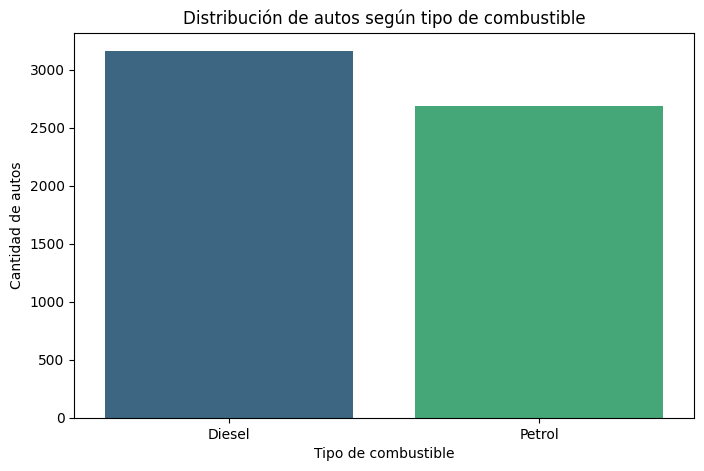

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Fuel_Type', order=df['Fuel_Type'].value_counts().index, palette='viridis')
plt.title('Distribución de autos según tipo de combustible')
plt.xlabel('Tipo de combustible')
plt.ylabel('Cantidad de autos')
plt.show()


**Interpretación:** El inventario está bastante balanceado entre `Diesel` (3161 autos) y `Petrol` (2684 autos), con una leve mayoría de Diesel (~54%). No hay una categoría que domine abrumadoramente, lo cual sugiere que ambos tipos de combustible tienen una demanda de reventa consolidada en el mercado indio de usados.

**Recomendación:** Como tomador de decisiones (p. ej. un comprador de flota para reventa), conviene mantener inventario diversificado entre ambos combustibles en lugar de apostar solo por uno, ya que ninguno domina de forma aplastante el mercado.

## 17. Gráfico de pie

Proporción de una variable categórica binaria o con pocas categorías (ej. `Transmission`).

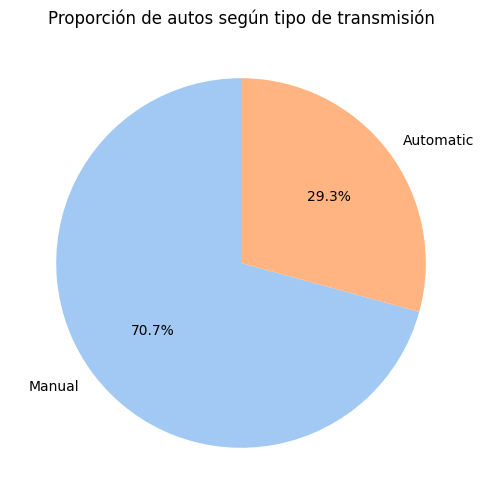

In [33]:
transmission_counts = df['Transmission'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(transmission_counts, labels=transmission_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Proporción de autos según tipo de transmisión')
plt.show()


**Interpretación:** El 70.7% de los autos son de transmisión `Manual` y solo el 29.3% son `Automatic`. Esto indica que el mercado de usados analizado está dominado por autos manuales, más económicos y comunes en el segmento medio, mientras que los automáticos —generalmente asociados a modelos más nuevos o de gama más alta— son minoría.

**Recomendación:** Si el objetivo de negocio es maximizar rotación de inventario, priorizar la compra de autos Manual tiene sentido por su mayor demanda relativa; sin embargo, dado que (como se verá en el punto 21) los automáticos suelen tener precio de reventa más alto, también representan un nicho de mayor margen por unidad.

## 18. Histograma

Distribución de una variable numérica (ej. `Price`). Indicar si es simétrica o sesgada.

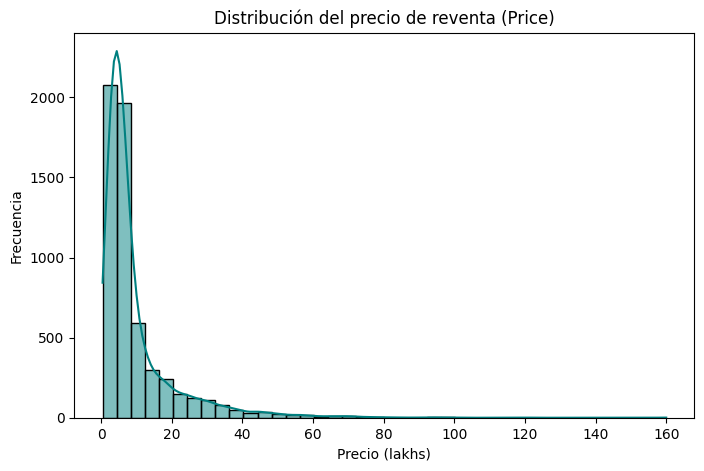

Media: 9.65
Mediana: 5.75
Skewness: 3.31


In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=40, kde=True, color='teal')
plt.title('Distribución del precio de reventa (Price)')
plt.xlabel('Precio (lakhs)')
plt.ylabel('Frecuencia')
plt.show()

print("Media:", df['Price'].mean().round(2))
print("Mediana:", df['Price'].median())
print("Skewness:", df['Price'].skew().round(2))


**Interpretación:** La distribución de `Price` es claramente **asimétrica hacia la derecha (sesgo positivo)**, con un coeficiente de asimetría de ~3.31. La media (9.65 lakhs) es casi el doble de la mediana (5.75 lakhs), lo que confirma que unos pocos autos de lujo muy caros (como los identificados en el punto 15) alargan la cola derecha y empujan el promedio hacia arriba, mientras la mayoría de los autos se concentra en precios bajos-medios.

**Recomendación:** Para reportar o modelar `Price`, es preferible usar la mediana (o una transformación logarítmica) en lugar de la media como medida de tendencia central, ya que la media puede dar una impresión engañosa del precio "típico" de un auto usado en este mercado.

## 19. Scatter plot

Relación entre dos variables numéricas (ej. `Kilometers_Driven` vs `Price`). Indicar si hay correlación positiva, negativa o nula.

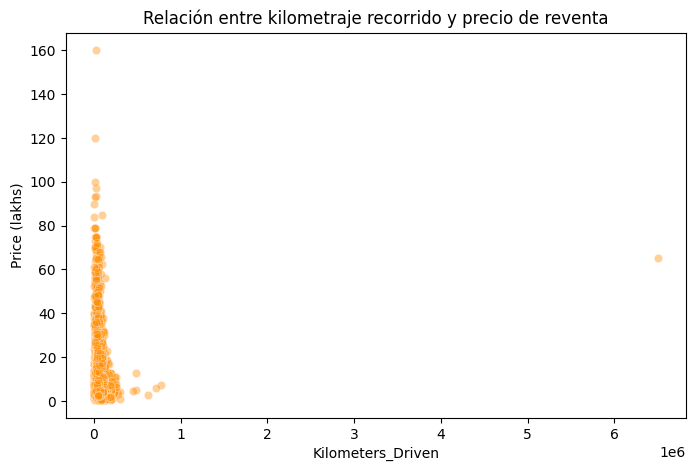

Correlación de Pearson: -0.0086


In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Kilometers_Driven', y='Price', alpha=0.4, color='darkorange')
plt.title('Relación entre kilometraje recorrido y precio de reventa')
plt.xlabel('Kilometers_Driven')
plt.ylabel('Price (lakhs)')
plt.show()

print("Correlación de Pearson:", df['Kilometers_Driven'].corr(df['Price']).round(4))


**Interpretación:** La correlación entre `Kilometers_Driven` y `Price` es prácticamente **nula** (r ≈ -0.009), contrario a la intuición de que a mayor kilometraje, menor precio. Esto se explica porque `Price` está mucho más influenciado por la marca/segmento del auto (un SUV de lujo con 60,000 km sigue costando mucho más que un auto económico con 20,000 km) que por el desgaste medido en kilómetros; también puede notarse en el gráfico un punto extremo con kilometraje muy alto (el outlier identificado en el punto 11), que aporta ruido a la relación.

**Recomendación:** No conviene usar `Kilometers_Driven` de forma aislada como predictor lineal de `Price` en un futuro modelo; es más útil combinarlo con variables como marca, año o tipo de combustible (interacción), o analizarlo dentro de cada segmento de auto por separado.

## 20. Boxplot

Al menos una variable numérica, con `.boxplot()` o seaborn. Identificar visualmente outliers y relacionarlo con el punto 11.

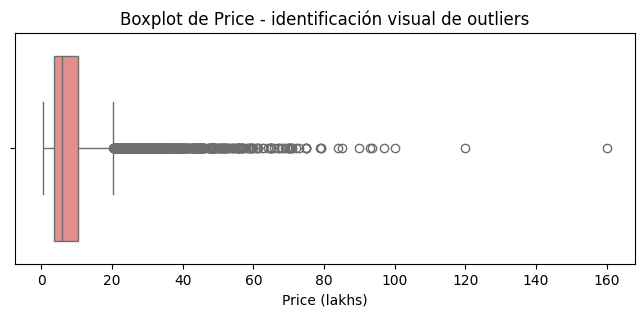

In [36]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Price'], color='lightcoral')
plt.title('Boxplot de Price - identificación visual de outliers')
plt.xlabel('Price (lakhs)')
plt.show()


**Interpretación:** El boxplot muestra visualmente una gran cantidad de puntos por encima del bigote superior, lo que confirma de forma gráfica los 679 outliers superiores calculados con el criterio IQR en el punto 11 (límite superior ≈ 20.3 lakhs). La caja (IQR) está muy comprimida cerca del origen en comparación con la cola de outliers, lo cual es consistente con el fuerte sesgo positivo visto en el histograma del punto 18.

**Recomendación:** Estos outliers no deben eliminarse sin más: representan un segmento real del mercado (autos de lujo). Para análisis o modelado, conviene tratarlos como un segmento aparte (p. ej. una variable binaria "es_lujo") en lugar de descartarlos, o aplicar una transformación (log) que reduzca su influencia desproporcionada.

## 21. Gráfico de líneas / boxplot comparativo

El dataset no tiene variable temporal continua, por lo que se reemplaza por un segundo boxplot comparando la variable numérica principal (`Price`) entre 2 o más categorías (ej. `Price` por `Fuel_Type` o por `Transmission`).

C:\Users\jjesc\AppData\Local\Temp\ipykernel_41296\3649308015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel_Type', y='Price', palette='Set2')


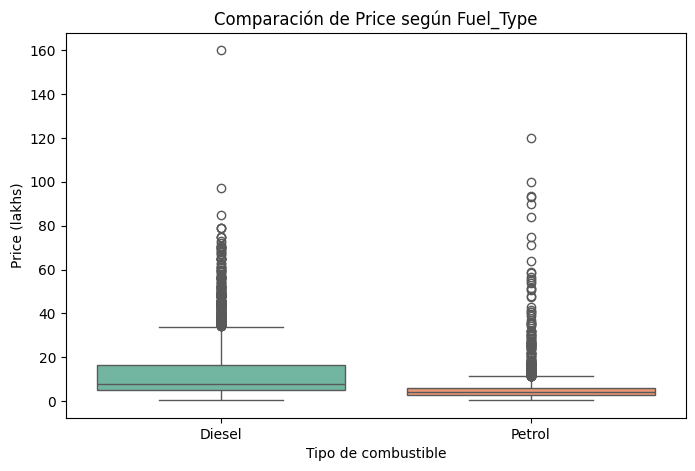

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Fuel_Type', y='Price', palette='Set2')
plt.title('Comparación de Price según Fuel_Type')
plt.xlabel('Tipo de combustible')
plt.ylabel('Price (lakhs)')
plt.show()


**Interpretación:** Los autos `Diesel` tienen una mediana de precio (7.85 lakhs) notablemente más alta que los `Petrol` (4.21 lakhs), y también presentan una caja (IQR) más amplia y más outliers en la parte alta — coherente con el promedio calculado en el punto 14 (12.96 vs 5.76 lakhs). Esto refuerza que `Fuel_Type` está asociado al segmento del vehículo: los Diesel incluyen más SUVs y sedanes grandes/premium, mientras los Petrol tienden a vehículos más compactos y económicos.

**Recomendación:** `Fuel_Type` es una variable categórica con buen poder discriminante sobre `Price` y debería incluirse como feature relevante en un futuro modelo predictivo, en lugar de descartarla por ser categórica.

---

# Fase 5 — Conclusiones

## 22. Conclusiones generales

Redacte un párrafo de conclusiones generales respondiendo: ¿qué se aprendió del dataset?, ¿qué variables parecen más relevantes?, ¿qué limpieza fue necesaria y por qué?, ¿qué preguntas quedarían abiertas para un futuro modelo de Machine Learning sobre estos datos?
Incluya un subplot (2,2) con los gráficos que se consideren más importantes para explicar los hallazgos generales.

C:\Users\jjesc\AppData\Local\Temp\ipykernel_41296\3784810851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel_Type', y='Price', palette='Set2', ax=axes[0,1])


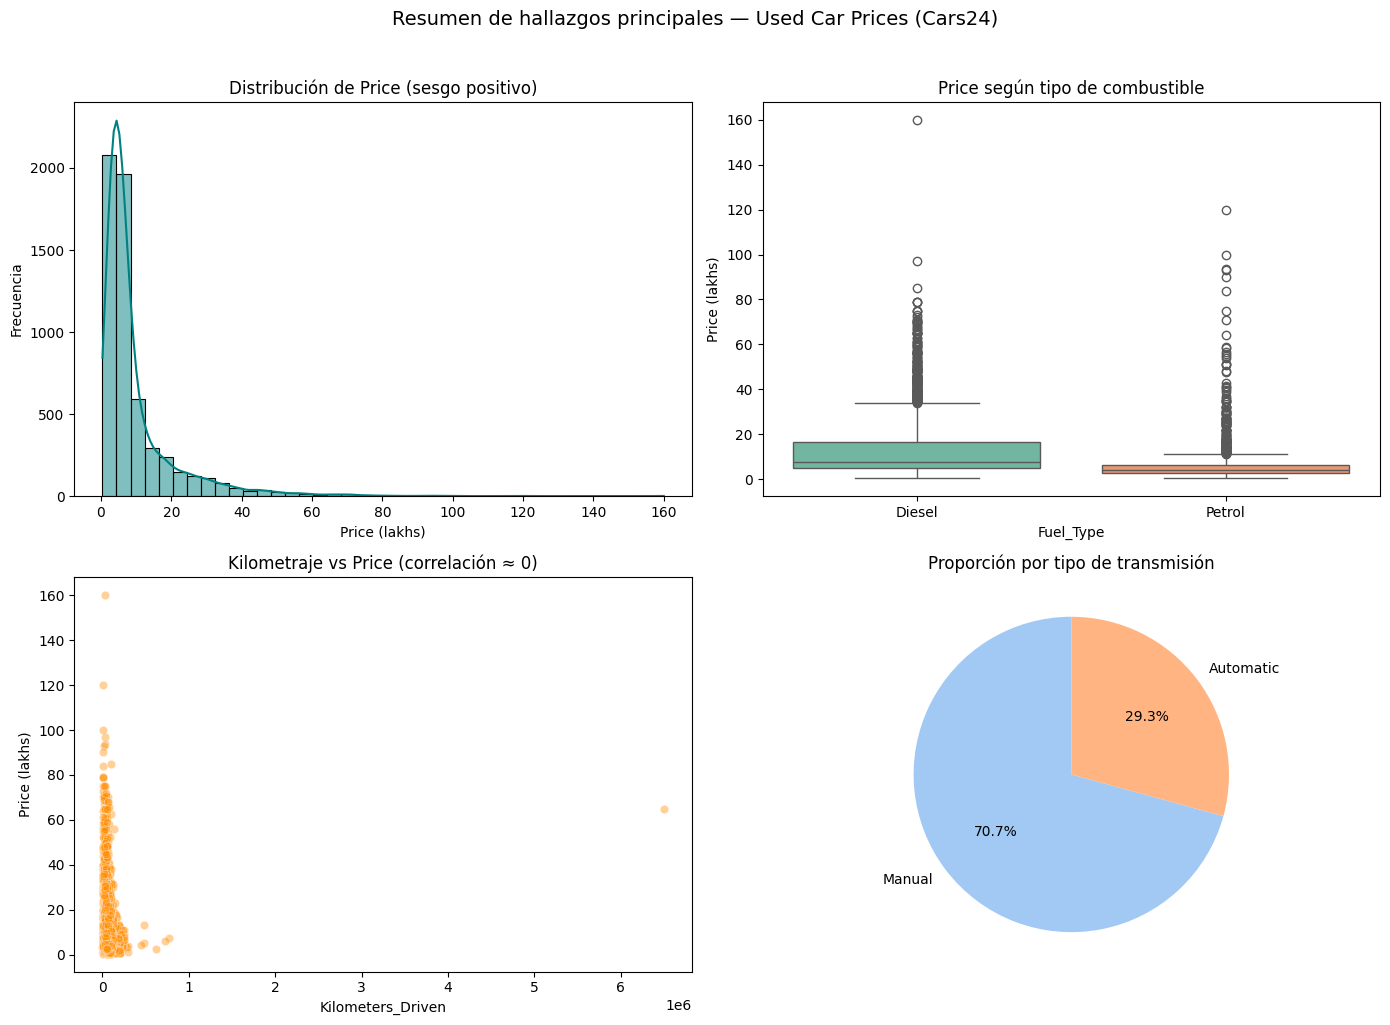

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de Price (sesgo positivo)
sns.histplot(df['Price'], bins=40, kde=True, color='teal', ax=axes[0,0])
axes[0,0].set_title('Distribución de Price (sesgo positivo)')
axes[0,0].set_xlabel('Price (lakhs)')
axes[0,0].set_ylabel('Frecuencia')

# 2. Price según Fuel_Type (Diesel vs Petrol)
sns.boxplot(data=df, x='Fuel_Type', y='Price', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Price según tipo de combustible')
axes[0,1].set_xlabel('Fuel_Type')
axes[0,1].set_ylabel('Price (lakhs)')

# 3. Kilometers_Driven vs Price (correlación prácticamente nula)
sns.scatterplot(data=df, x='Kilometers_Driven', y='Price', alpha=0.4, color='darkorange', ax=axes[1,0])
axes[1,0].set_title('Kilometraje vs Price (correlación ≈ 0)')
axes[1,0].set_xlabel('Kilometers_Driven')
axes[1,0].set_ylabel('Price (lakhs)')

# 4. Distribución de Transmission (Manual vs Automatic)
transmission_counts = df['Transmission'].value_counts()
axes[1,1].pie(transmission_counts, labels=transmission_counts.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), startangle=90)
axes[1,1].set_title('Proporción por tipo de transmisión')

plt.suptitle('Resumen de hallazgos principales — Used Car Prices (Cars24)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Conclusiones generales**

A partir del análisis del dataset de autos usados de Cars24 (India), lo más relevante que aprendimos es que el precio de reventa (`Price`) depende mucho más del **segmento/tipo de vehículo** que del desgaste por uso: la correlación entre `Kilometers_Driven` y `Price` resultó prácticamente nula (r ≈ -0.009), un resultado contraintuitivo pero consistente en todo el análisis. `Price` además mostró una distribución fuertemente sesgada a la derecha (skewness ≈ 3.31): la mayoría de los autos se vende en rangos bajos-medios, mientras un pequeño grupo de vehículos de lujo (Land Rover, Lamborghini, Jaguar, BMW) infla el promedio muy por encima de la mediana — los mismos identificados como outliers superiores por el criterio IQR del punto 11. Las variables que parecen más relevantes para explicar `Price` son `Fuel_Type` (los Diesel casi duplican en precio promedio a los Petrol: 12.96 vs 5.76 lakhs), `Transmission`, `Power`/`Engine`/`Year`, y presumiblemente la marca/modelo contenida en `Name`, que quedan como candidatas naturales para un futuro modelo predictivo. La limpieza fue necesaria en varios frentes: se eliminaron columnas sin valor analítico o con demasiados nulos (`Unnamed: 0`, `New_Price` con 86% de nulos); se convirtieron a numéricas columnas que venían como texto con unidad (`Engine`, `Power`, `Mileage`), unificando además las dos unidades distintas de `Mileage` (kmpl y km/kg); se imputó con la mediana en columnas con pocos nulos (`Seats`, `Engine`, `Power`); y se eliminaron 2 filas de autos eléctricos sin dato de `Mileage`, por no tener sentido conceptual imputarlas. Quedan abiertas varias preguntas para un futuro modelo de Machine Learning: ¿conviene modelar `Price` en escala logarítmica dado su sesgo?, ¿qué tanto aporta extraer la marca/modelo de `Name` como variable categórica adicional?, ¿debería tratarse el segmento de lujo como un modelo separado en vez de como outliers a corregir?, y ¿qué tanto mejoran las predicciones al incluir interacciones entre `Fuel_Type`/`Transmission` y `Year`/`Kilometers_Driven`?